In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "For signal strength (judgement ⑧) — a subjective ordinal call (weak/moderate/strong) — how self-consistent is each model, how much do the models agree with each other, and do they track the human coder (Polina)?"

*Judgement ⑧ of 11 · subjective family: no right answer, so the axis is consistency (Krippendorff's ordinal alpha), not accuracy. Sentiment (⑦) is analysed separately.*

In [2]:

import json, sys
sys.path.insert(0, r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/scripts")
import compute_alphas as ca

RUNS = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j78_classify_runs.json", encoding="utf-8"))
MAN = RUNS["manifest"]; results = RUNS["results"]; polina = RUNS["polina"]
CAND = MAN["candidate_models"]; K = MAN["k"]; PRICES = {'thinkingmachines/inkling': 1.0, 'openrouter/auto-beta': -1000000.0, 'moonshotai/kimi-k3': 3.0, 'meta/muse-spark-1.1': 1.25, 'kwaipilot/kat-coder-air-v2.5': 0.15, 'kwaipilot/kat-coder-pro-v2.5': 0.74, 'openai/gpt-5.6-luna-pro': 1.0, 'openai/gpt-5.6-luna': 1.0, 'openai/gpt-5.6-terra-pro': 2.5, 'openai/gpt-5.6-terra': 2.5, 'openai/gpt-5.6-sol-pro': 5.0, 'openai/gpt-5.6-sol': 5.0, 'x-ai/grok-4.5': 2.0, '~x-ai/grok-latest': 2.0, 'aion-labs/aion-3.0-mini': 0.7, 'aion-labs/aion-3.0': 3.0, 'tencent/hy3': 0.2, 'tencent/hy3:free': 0.0, 'poolside/laguna-xs-2.1': 0.06, 'poolside/laguna-xs-2.1:free': 0.0, 'anthropic/claude-sonnet-5': 2.0, 'google/gemini-3.1-flash-lite-image': 0.25, 'nex-agi/nex-n2-mini': 0.025, 'sakana/fugu-ultra': 5.0, 'google/gemini-3.1-flash-image': 0.5, 'google/gemini-3-pro-image': 2.0, 'cohere/north-mini-code:free': 0.0, 'z-ai/glm-5.2': 0.419, 'openrouter/fusion': -1000000.0, 'moonshotai/kimi-k2.7-code': 1.0, '~anthropic/claude-fable-latest': 10.0, 'anthropic/claude-fable-5': 10.0, 'nex-agi/nex-n2-pro': 0.25, 'nvidia/nemotron-3.5-content-safety:free': 0.0, 'nvidia/nemotron-3-ultra-550b-a55b': 0.6, 'nvidia/nemotron-3-ultra-550b-a55b:free': 0.0, 'qwen/qwen3.7-plus': 0.32, 'minimax/minimax-m3': 0.3, 'stepfun/step-3.7-flash': 0.2, 'anthropic/claude-opus-4.8-fast': 10.0, 'anthropic/claude-opus-4.8': 5.0, 'qwen/qwen3.7-max': 1.475, 'x-ai/grok-build-0.1': 1.0, 'google/gemini-3.5-flash': 1.5, 'anthropic/claude-opus-4.7-fast': 30.0, 'perceptron/perceptron-mk1': 0.15, 'inclusionai/ring-2.6-1t': 0.075, 'google/gemini-3.1-flash-lite': 0.25, 'openai/gpt-chat-latest': 5.0, 'x-ai/grok-4.3': 1.25, 'ibm-granite/granite-4.1-8b': 0.05, 'mistralai/mistral-medium-3-5': 1.5, 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free': 0.0, 'poolside/laguna-m.1': 0.2, 'poolside/laguna-m.1:free': 0.0, '~anthropic/claude-haiku-latest': 1.0, '~openai/gpt-mini-latest': 0.75, '~google/gemini-pro-latest': 2.0, '~moonshotai/kimi-latest': 3.0, '~google/gemini-flash-latest': 1.5, '~anthropic/claude-sonnet-latest': 2.0, '~openai/gpt-latest': 5.0, 'qwen/qwen3.5-plus-20260420': 0.3, 'qwen/qwen3.6-flash': 0.188, 'qwen/qwen3.6-35b-a3b': 0.14, 'qwen/qwen3.6-max-preview': 1.04, 'qwen/qwen3.6-27b': 0.45, 'openai/gpt-5.5-pro': 30.0, 'openai/gpt-5.5': 5.0, 'deepseek/deepseek-v4-pro': 0.435, 'deepseek/deepseek-v4-flash': 0.098, 'inclusionai/ling-2.6-1t': 0.075, 'tencent/hy3-preview': 0.063, 'xiaomi/mimo-v2.5-pro': 0.435, 'xiaomi/mimo-v2.5': 0.14, 'openai/gpt-5.4-image-2': 8.0, 'inclusionai/ling-2.6-flash': 0.01, '~anthropic/claude-opus-latest': 5.0, 'openrouter/pareto-code': -1000000.0, 'moonshotai/kimi-k2.6': 0.95, 'anthropic/claude-opus-4.7': 5.0, 'z-ai/glm-5.1': 0.966, 'google/gemma-4-26b-a4b-it': 0.1, 'google/gemma-4-26b-a4b-it:free': 0.0, 'google/gemma-4-31b-it': 0.22, 'google/gemma-4-31b-it:free': 0.0, 'qwen/qwen3.6-plus': 0.325, 'z-ai/glm-5v-turbo': 1.2, 'arcee-ai/trinity-large-thinking': 0.25, 'x-ai/grok-4.20-multi-agent': 1.25, 'x-ai/grok-4.20': 1.25, 'google/lyria-3-pro-preview': 0.0, 'google/lyria-3-clip-preview': 0.0, 'kwaipilot/kat-coder-pro-v2': 0.3, 'rekaai/reka-edge': 0.1, 'minimax/minimax-m2.7': 0.25, 'openai/gpt-5.4-nano': 0.2, 'openai/gpt-5.4-mini': 0.75, 'mistralai/mistral-small-2603': 0.15, 'z-ai/glm-5-turbo': 1.2, 'nvidia/nemotron-3-super-120b-a12b': 0.21, 'nvidia/nemotron-3-super-120b-a12b:free': 0.0, 'bytedance-seed/seed-2.0-lite': 0.25, 'qwen/qwen3.5-9b': 0.1, 'openai/gpt-5.4-pro': 30.0, 'openai/gpt-5.4': 2.5, 'inception/mercury-2': 0.25, 'openai/gpt-5.3-chat': 1.75, 'google/gemini-3.1-flash-lite-preview': 0.25, 'bytedance-seed/seed-2.0-mini': 0.1, 'google/gemini-3.1-flash-image-preview': 0.5, 'qwen/qwen3.5-35b-a3b': 0.14, 'qwen/qwen3.5-27b': 0.26, 'qwen/qwen3.5-122b-a10b': 0.26, 'qwen/qwen3.5-flash-02-23': 0.065, 'google/gemini-3.1-pro-preview-customtools': 2.0, 'openai/gpt-5.3-codex': 1.75, 'aion-labs/aion-2.0': 0.8, 'google/gemini-3.1-pro-preview': 2.0, 'anthropic/claude-sonnet-4.6': 3.0, 'qwen/qwen3.5-plus-02-15': 0.26, 'qwen/qwen3.5-397b-a17b': 0.39, 'minimax/minimax-m2.5': 0.15, 'z-ai/glm-5': 0.95, 'qwen/qwen3-max-thinking': 0.78, 'anthropic/claude-opus-4.6': 5.0, 'qwen/qwen3-coder-next': 0.11, 'openrouter/free': 0.0, 'stepfun/step-3.5-flash': 0.1, 'moonshotai/kimi-k2.5': 0.57, 'upstage/solar-pro-3': 0.15, 'minimax/minimax-m2-her': 0.3, 'writer/palmyra-x5': 0.6, 'openai/gpt-audio': 2.5, 'openai/gpt-audio-mini': 0.6, 'z-ai/glm-4.7-flash': 0.061, 'openai/gpt-5.2-codex': 1.75, 'bytedance-seed/seed-1.6-flash': 0.075, 'bytedance-seed/seed-1.6': 0.25, 'minimax/minimax-m2.1': 0.3, 'z-ai/glm-4.7': 0.4, 'google/gemini-3-flash-preview': 0.5, 'nvidia/nemotron-3-nano-30b-a3b': 0.05, 'nvidia/nemotron-3-nano-30b-a3b:free': 0.0, 'openai/gpt-5.2-chat': 1.75, 'openai/gpt-5.2-pro': 21.0, 'openai/gpt-5.2': 1.75, 'mistralai/devstral-2512': 0.4, 'relace/relace-search': 1.0, 'z-ai/glm-4.6v': 0.3, 'openrouter/bodybuilder': -1000000.0, 'openai/gpt-5.1-codex-max': 1.25, 'amazon/nova-2-lite-v1': 0.3, 'mistralai/ministral-14b-2512': 0.2, 'mistralai/ministral-8b-2512': 0.15, 'mistralai/ministral-3b-2512': 0.1, 'mistralai/mistral-large-2512': 0.5, 'deepseek/deepseek-v3.2': 0.269, 'anthropic/claude-opus-4.5': 5.0, 'allenai/olmo-3-32b-think': 0.15, 'google/gemini-3-pro-image-preview': 2.0, 'deepcogito/cogito-v2.1-671b': 1.25, 'openai/gpt-5.1': 1.25, 'openai/gpt-5.1-chat': 1.25, 'openai/gpt-5.1-codex': 1.25, 'openai/gpt-5.1-codex-mini': 0.25, 'moonshotai/kimi-k2-thinking': 0.6, 'amazon/nova-premier-v1': 2.5, 'perplexity/sonar-pro-search': 3.0, 'mistralai/voxtral-small-24b-2507': 0.1, 'openai/gpt-oss-safeguard-20b': 0.075, 'nvidia/nemotron-nano-12b-v2-vl:free': 0.0, 'minimax/minimax-m2': 0.255, 'qwen/qwen3-vl-32b-instruct': 0.104, 'ibm-granite/granite-4.0-h-micro': 0.017, 'openai/gpt-5-image-mini': 2.5, 'anthropic/claude-haiku-4.5': 1.0, 'qwen/qwen3-vl-8b-thinking': 0.117, 'qwen/qwen3-vl-8b-instruct': 0.117, 'openai/gpt-5-image': 10.0, 'openai/o3-deep-research': 10.0, 'openai/o4-mini-deep-research': 2.0, 'google/gemini-2.5-flash-image': 0.3, 'qwen/qwen3-vl-30b-a3b-thinking': 0.13, 'qwen/qwen3-vl-30b-a3b-instruct': 0.13, 'openai/gpt-5-pro': 15.0, 'z-ai/glm-4.6': 0.5, 'anthropic/claude-sonnet-4.5': 3.0, 'deepseek/deepseek-v3.2-exp': 0.27, 'thedrummer/cydonia-24b-v4.1': 0.3, 'relace/relace-apply-3': 0.85, 'qwen/qwen3-vl-235b-a22b-thinking': 0.26, 'qwen/qwen3-vl-235b-a22b-instruct': 0.21, 'qwen/qwen3-max': 0.78, 'qwen/qwen3-coder-plus': 0.65, 'openai/gpt-5-codex': 1.25, 'deepseek/deepseek-v3.1-terminus': 0.27, 'qwen/qwen3-coder-flash': 0.195, 'qwen/qwen3-next-80b-a3b-thinking': 0.098, 'qwen/qwen3-next-80b-a3b-instruct': 0.1, 'qwen/qwen3-next-80b-a3b-instruct:free': 0.0, 'qwen/qwen-plus-2025-07-28': 0.26, 'qwen/qwen-plus-2025-07-28:thinking': 0.26, 'nvidia/nemotron-nano-9b-v2:free': 0.0, 'moonshotai/kimi-k2-0905': 0.6, 'qwen/qwen3-30b-a3b-thinking-2507': 0.13, 'nousresearch/hermes-4-70b': 0.13, 'nousresearch/hermes-4-405b': 1.0, 'deepseek/deepseek-chat-v3.1': 0.25, 'mistralai/mistral-medium-3.1': 0.4, 'z-ai/glm-4.5v': 0.6, 'ai21/jamba-large-1.7': 2.0, 'openai/gpt-5-chat': 1.25, 'openai/gpt-5': 1.25, 'openai/gpt-5-mini': 0.25, 'openai/gpt-5-nano': 0.05, 'openai/gpt-oss-120b': 0.037, 'openai/gpt-oss-20b': 0.03, 'openai/gpt-oss-20b:free': 0.0, 'anthropic/claude-opus-4.1': 15.0, 'mistralai/codestral-2508': 0.3, 'qwen/qwen3-coder-30b-a3b-instruct': 0.07, 'qwen/qwen3-30b-a3b-instruct-2507': 0.1, 'z-ai/glm-4.5': 0.6, 'z-ai/glm-4.5-air': 0.13, 'qwen/qwen3-235b-a22b-thinking-2507': 0.15, 'qwen/qwen3-coder': 0.3, 'qwen/qwen3-coder:free': 0.0, 'bytedance/ui-tars-1.5-7b': 0.1, 'google/gemini-2.5-flash-lite': 0.1, 'qwen/qwen3-235b-a22b-2507': 0.09, 'moonshotai/kimi-k2': 0.57, 'cognitivecomputations/dolphin-mistral-24b-venice-edition': 0.2, 'cognitivecomputations/dolphin-mistral-24b-venice-edition:free': 0.0, 'tencent/hunyuan-a13b-instruct': 0.14, 'morph/morph-v3-large': 0.9, 'morph/morph-v3-fast': 0.8, 'baidu/ernie-4.5-vl-424b-a47b': 0.42, 'mistralai/mistral-small-3.2-24b-instruct': 0.1, 'minimax/minimax-m1': 0.55, 'google/gemini-2.5-flash': 0.3, 'google/gemini-2.5-pro': 1.25, 'openai/o3-pro': 20.0, 'google/gemini-2.5-pro-preview': 1.25, 'deepseek/deepseek-r1-0528': 0.5, 'anthropic/claude-opus-4': 15.0, 'anthropic/claude-sonnet-4': 3.0, 'google/gemma-3n-e4b-it': 0.06, 'mistralai/mistral-medium-3': 0.4, 'google/gemini-2.5-pro-preview-05-06': 1.25, 'arcee-ai/virtuoso-large': 0.75, 'meta-llama/llama-guard-4-12b': 0.18, 'qwen/qwen3-30b-a3b': 0.13, 'qwen/qwen3-8b': 0.117, 'qwen/qwen3-14b': 0.12, 'qwen/qwen3-32b': 0.08, 'qwen/qwen3-235b-a22b': 0.455, 'openai/o4-mini-high': 1.1, 'openai/o3': 2.0, 'openai/o4-mini': 1.1, 'openai/gpt-4.1': 2.0, 'openai/gpt-4.1-mini': 0.4, 'openai/gpt-4.1-nano': 0.1, 'meta-llama/llama-4-maverick': 0.2, 'meta-llama/llama-4-scout': 0.1, 'deepseek/deepseek-chat-v3-0324': 0.27, 'openai/o1-pro': 150.0, 'mistralai/mistral-small-3.1-24b-instruct': 0.351, 'google/gemma-3-4b-it': 0.05, 'google/gemma-3-12b-it': 0.05, 'cohere/command-a': 2.5, 'openai/gpt-4o-mini-search-preview': 0.15, 'openai/gpt-4o-search-preview': 2.5, 'rekaai/reka-flash-3': 0.1, 'google/gemma-3-27b-it': 0.1, 'thedrummer/skyfall-36b-v2': 0.55, 'perplexity/sonar-reasoning-pro': 2.0, 'perplexity/sonar-pro': 3.0, 'perplexity/sonar-deep-research': 2.0, 'mistralai/mistral-saba': 0.2, 'openai/o3-mini-high': 1.1, 'aion-labs/aion-rp-llama-3.1-8b': 0.8, 'qwen/qwen2.5-vl-72b-instruct': 0.8, 'qwen/qwen-plus': 0.26, 'openai/o3-mini': 1.1, 'mistralai/mistral-small-24b-instruct-2501': 0.05, 'perplexity/sonar': 1.0, 'deepseek/deepseek-r1-distill-llama-70b': 0.8, 'deepseek/deepseek-r1': 0.7, 'minimax/minimax-01': 0.2, 'microsoft/phi-4': 0.07, 'deepseek/deepseek-chat': 0.2, 'sao10k/l3.3-euryale-70b': 0.65, 'openai/o1': 15.0, 'cohere/command-r7b-12-2024': 0.037, 'meta-llama/llama-3.3-70b-instruct': 0.13, 'meta-llama/llama-3.3-70b-instruct:free': 0.0, 'amazon/nova-lite-v1': 0.06, 'amazon/nova-micro-v1': 0.035, 'amazon/nova-pro-v1': 0.8, 'openai/gpt-4o-2024-11-20': 2.5, 'mistralai/mistral-large-2407': 2.0, 'qwen/qwen-2.5-coder-32b-instruct': 0.66, 'thedrummer/unslopnemo-12b': 0.4, 'anthracite-org/magnum-v4-72b': 3.0, 'qwen/qwen-2.5-7b-instruct': 0.04, 'inflection/inflection-3-pi': 2.5, 'inflection/inflection-3-productivity': 2.5, 'thedrummer/rocinante-12b': 0.25, 'meta-llama/llama-3.2-1b-instruct': 0.027, 'meta-llama/llama-3.2-3b-instruct': 0.051, 'meta-llama/llama-3.2-3b-instruct:free': 0.0, 'qwen/qwen-2.5-72b-instruct': 0.36, 'cohere/command-r-08-2024': 0.15, 'cohere/command-r-plus-08-2024': 2.5, 'sao10k/l3.1-euryale-70b': 0.85, 'nousresearch/hermes-3-llama-3.1-70b': 0.7, 'nousresearch/hermes-3-llama-3.1-405b': 1.0, 'nousresearch/hermes-3-llama-3.1-405b:free': 0.0, 'sao10k/l3-lunaris-8b': 0.04, 'openai/gpt-4o-2024-08-06': 2.5, 'meta-llama/llama-3.1-70b-instruct': 0.4, 'meta-llama/llama-3.1-8b-instruct': 0.05, 'mistralai/mistral-nemo': 0.019, 'openai/gpt-4o-mini': 0.15, 'openai/gpt-4o-mini-2024-07-18': 0.15, 'google/gemma-2-27b-it': 0.65, 'openai/gpt-4o': 2.5, 'openai/gpt-4o-2024-05-13': 5.0, 'mistralai/mixtral-8x22b-instruct': 2.0, 'microsoft/wizardlm-2-8x22b': 0.62, 'openai/gpt-4-turbo': 10.0, 'anthropic/claude-3-haiku': 0.25, 'mistralai/mistral-large': 2.0, 'openai/gpt-3.5-turbo-0613': 1.0, 'openai/gpt-4-turbo-preview': 10.0, 'openrouter/auto': -1000000.0, 'openai/gpt-3.5-turbo-instruct': 1.5, 'openai/gpt-3.5-turbo-16k': 3.0, 'mancer/weaver': 0.5, 'undi95/remm-slerp-l2-13b': 0.45, 'gryphe/mythomax-l2-13b': 0.06, 'openai/gpt-3.5-turbo': 0.5, 'openai/gpt-4': 30.0}
MODELS = [m.split("/")[-1] for m in CAND]
def short(m): return m.split("/")[-1]
def nsig(v):
    v = str(v).lower().strip() if v else ""
    return ca.SIG_FIX.get(v, v)

def pivot_alpha(dfr):
    dfr = dfr[dfr.v.isin(ca.SIGNAL_ORDER)]   # ordinal levels only (drop n/a / blank)
    if not len(dfr):
        return None
    m, _ = ca.pivot_field(dfr, "v")
    return ca.krippendorff_alpha_ordinal(m) if m.size else None

rows = []
for r in results:
    if r["run"] == 0 and not r["parse_failed"]:
        rows.append(dict(coder_id=short(r["model"]), sample_id=r["sample_id"], canonical_drug=r["drug"], v=nsig(r["signal"])))
for p in polina:
    rows.append(dict(coder_id="Polina", sample_id=p["sample_id"], canonical_drug=p["drug"], v=nsig(p["signal"])))
df = pd.DataFrame(rows); df = df[df.v.isin(ca.SIGNAL_ORDER)]
mo = df[df.coder_id != "Polina"]
mmat, _ = ca.pivot_field(mo, "v"); PANEL = ca.krippendorff_alpha_ordinal(mmat) if mmat.size else None
PAIR = ca.pairwise_alphas(mo, "v", ordinal=True)
VSP = {md: pivot_alpha(df[df.coder_id.isin([md, "Polina"])]) for md in MODELS}
WITHIN = {}
for m0 in CAND:
    rr = [r for r in results if r["model"] == m0 and not r["parse_failed"]]
    w = pd.DataFrame([dict(coder_id="r%d" % r["run"], sample_id=r["sample_id"], canonical_drug=r["drug"], v=nsig(r["signal"])) for r in rr])
    WITHIN[short(m0)] = pivot_alpha(w) if (len(w) and w.coder_id.nunique() >= 2) else None

def _f(x): return f"{x:.2f}" if (x is not None and x == x) else "n/a"
_vp = pd.Series({k: v for k, v in VSP.items() if v is not None})
display(Markdown(f"""
**Abstract.** Signal strength (⑧) — how *strong* a report is — is subjective and ordinal, so we measure
consistency, not accuracy, across **{len(MODELS)} models** on the Polina-labelled pairs (k={K}, temp 0), using
ordinal Krippendorff's α (a weak-vs-strong miss counts more than weak-vs-moderate). **Within-model** self-
agreement is high (median α **{_f(pd.Series(WITHIN).median())}**). But **cross-model** agreement is the lowest
of any judgement in the pipeline: panel α **{_f(PANEL)}** — models genuinely disagree on *how strong* a report
is, even when they agree on its direction. Against **Polina** the median is **{_f(_vp.median())}**. The reading:
signal is **intrinsically underdetermined** from short posts, which caps how much any downstream weighting by
signal strength can be trusted — and, as everywhere in the subjective family, agreement here is a diagnostic,
not a verdict.
"""))



**Abstract.** Signal strength (⑧) — how *strong* a report is — is subjective and ordinal, so we measure
consistency, not accuracy, across **22 models** on the Polina-labelled pairs (k=3, temp 0), using
ordinal Krippendorff's α (a weak-vs-strong miss counts more than weak-vs-moderate). **Within-model** self-
agreement is high (median α **0.90**). But **cross-model** agreement is the lowest
of any judgement in the pipeline: panel α **0.59** — models genuinely disagree on *how strong* a report
is, even when they agree on its direction. Against **Polina** the median is **0.37**. The reading:
signal is **intrinsically underdetermined** from short posts, which caps how much any downstream weighting by
signal strength can be trusted — and, as everywhere in the subjective family, agreement here is a diagnostic,
not a verdict.


## 1. Why signal is measured by consistency, not accuracy

Signal strength (weak / moderate / strong) rates how emphatic a report is — an interpretive, ordinal call with no external truth. So we measure consistency with **ordinal** Krippendorff's α (unlike sentiment's nominal α, an ordinal metric treats weak-vs-strong as a bigger miss than weak-vs-moderate): does a model agree with **itself**, the **other models**, and the **human**? The governing caveat is the same — agreement is a diagnostic of how underdetermined the call is, not proof anyone is right.

## 2. Within-model consistency at temperature 0

Each model against itself across the K repeats. High = stable; low = the model itself can't reproduce its own strength rating.

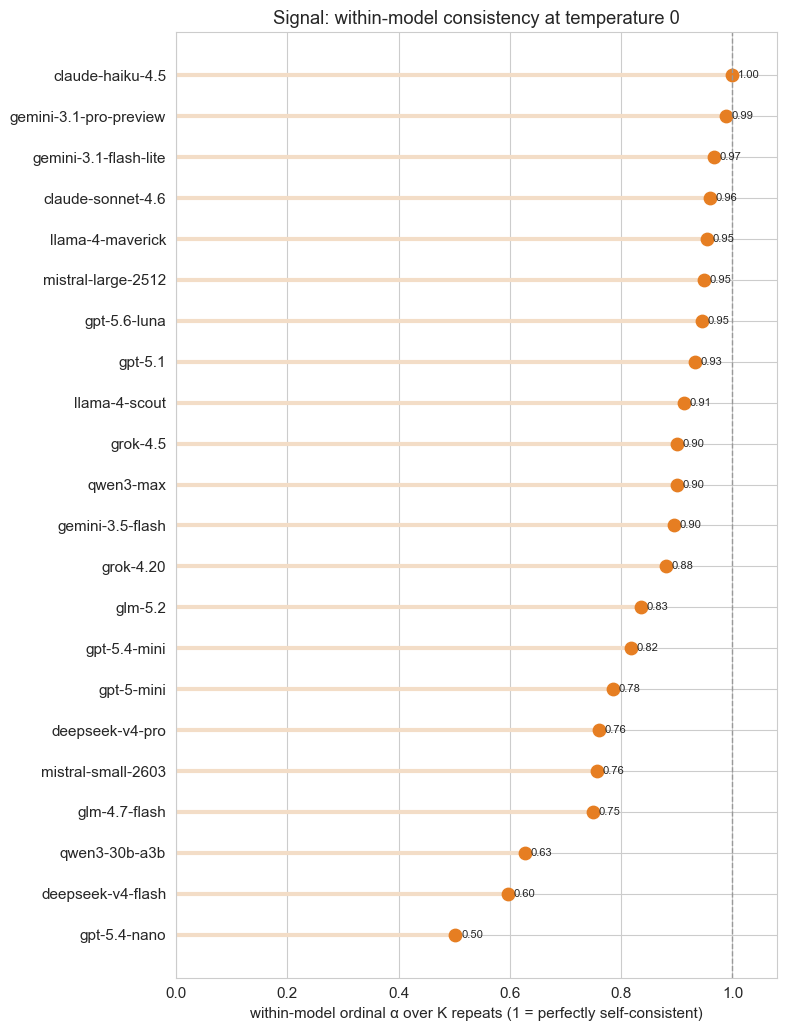

**What this shows:** within-model ordinal α is high (median **0.90**) — a model reproduces its own strength call at temperature 0. So the disagreement in §3 is real between-model divergence, not noise.

In [3]:

w = pd.DataFrame({"mshort": MODELS, "a": [WITHIN.get(m) for m in MODELS]}).dropna().sort_values("a")
ys = np.arange(len(w))
fig, ax = plt.subplots(figsize=(8, 1.2 + 0.42*len(w)))
ax.hlines(ys, 0, w.a, color="#f3ddc7", lw=3, zorder=1)
ax.scatter(w.a, ys, color="#e67e22", s=80, zorder=2)
for y, v in zip(ys, w.a):
    ax.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=8)
ax.axvline(1.0, ls="--", color="#999", lw=1)
ax.set_yticks(ys); ax.set_yticklabels(w.mshort); ax.set_xlim(min(0, w.a.min()-0.05), 1.08)
ax.set_xlabel("within-model ordinal α over K repeats (1 = perfectly self-consistent)")
ax.set_title("Signal: within-model consistency at temperature 0"); fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** within-model ordinal α is high (median **{w.a.median():.2f}**) — a model reproduces its "
  f"own strength call at temperature 0. So the disagreement in §3 is real between-model divergence, not noise."))


## 3. Cross-model agreement — the least-agreed judgement

The models against each other. Pairwise ordinal α heatmap + the panel α. Expect this to be the lowest in the pipeline: rating *strength* from a short post is genuinely underdetermined.

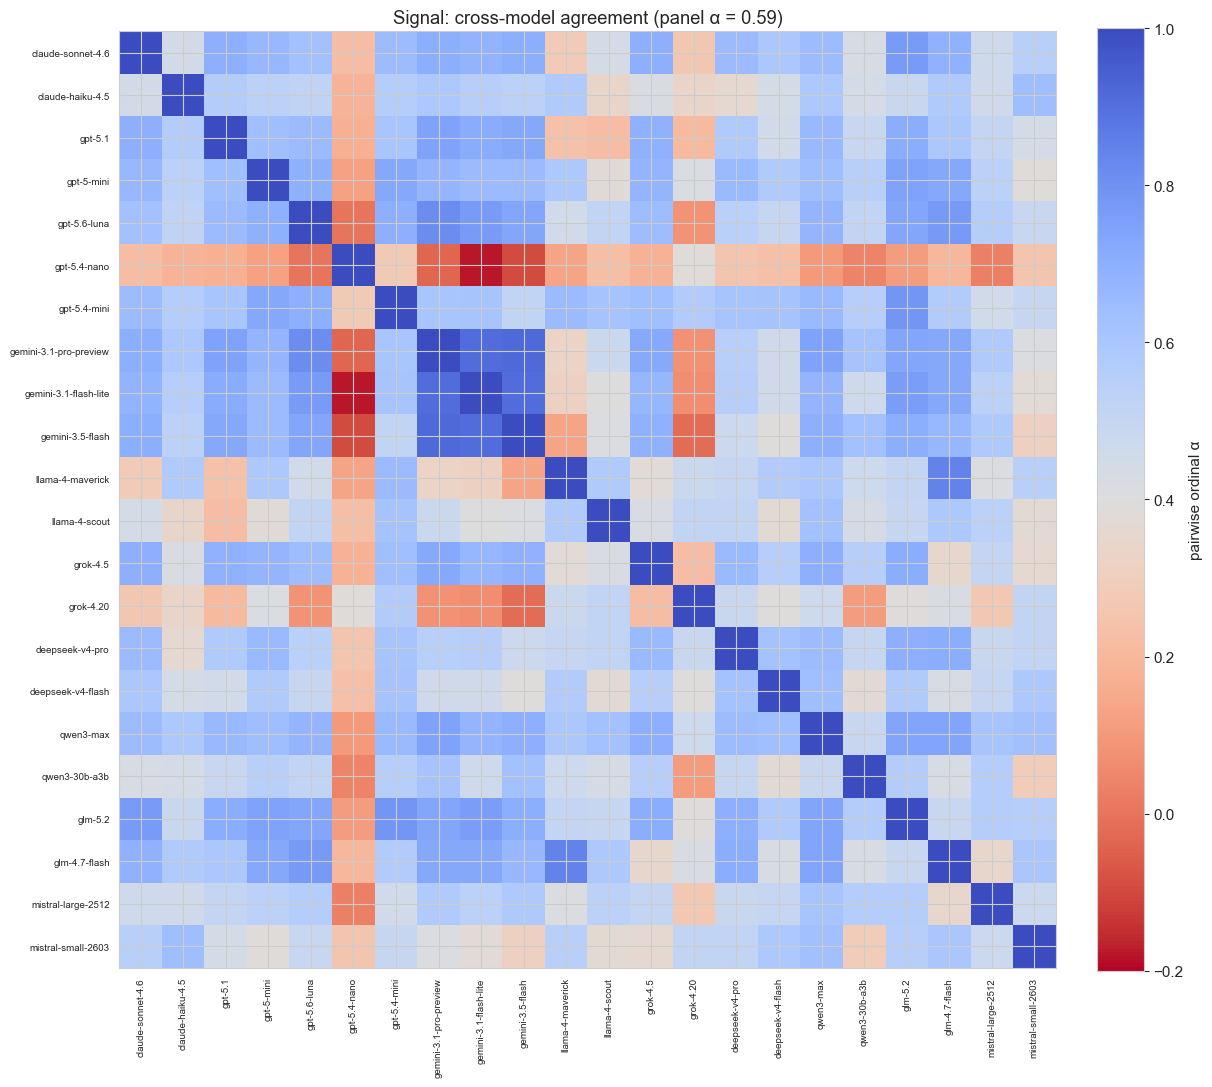

**What this shows:** panel ordinal α **0.59** — the lowest cross-model agreement of any judgement tested. Models concur on a report's *direction* far more than its *strength*. Biggest outlier **gpt-5.4-nano** (1 − mean pairwise 0.86). Low agreement here isn't a model failure so much as a property of the task: weak/moderate/strong is a fuzzy line on a 100–800-char post.

In [4]:

order = MODELS
M = PAIR.reindex(index=order, columns=order).astype(float)
fig, ax = plt.subplots(figsize=(0.42*len(order)+3, 0.42*len(order)+2))
im = ax.imshow(M.values, cmap="coolwarm_r", vmin=-0.2, vmax=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="pairwise ordinal α")
ax.set_title(f"Signal: cross-model agreement (panel α = {PANEL:.2f})")
fig.tight_layout(); plt.show()
out = {m: 1 - np.nanmean([PAIR.loc[m,o] for o in order if o != m]) for m in order}
od = pd.Series(out).sort_values(ascending=False)
display(Markdown(
  f"**What this shows:** panel ordinal α **{PANEL:.2f}** — the lowest cross-model agreement of any judgement "
  f"tested. Models concur on a report's *direction* far more than its *strength*. Biggest outlier "
  f"**{od.index[0]}** (1 − mean pairwise {od.iloc[0]:.2f}). Low agreement here isn't a model failure so much as "
  f"a property of the task: weak/moderate/strong is a fuzzy line on a 100–800-char post."))


## 4. Agreement with the human coder (Polina)

Each model vs Polina's signal labels — a **screen**, not a ranking (her codebook came from the same prompt).

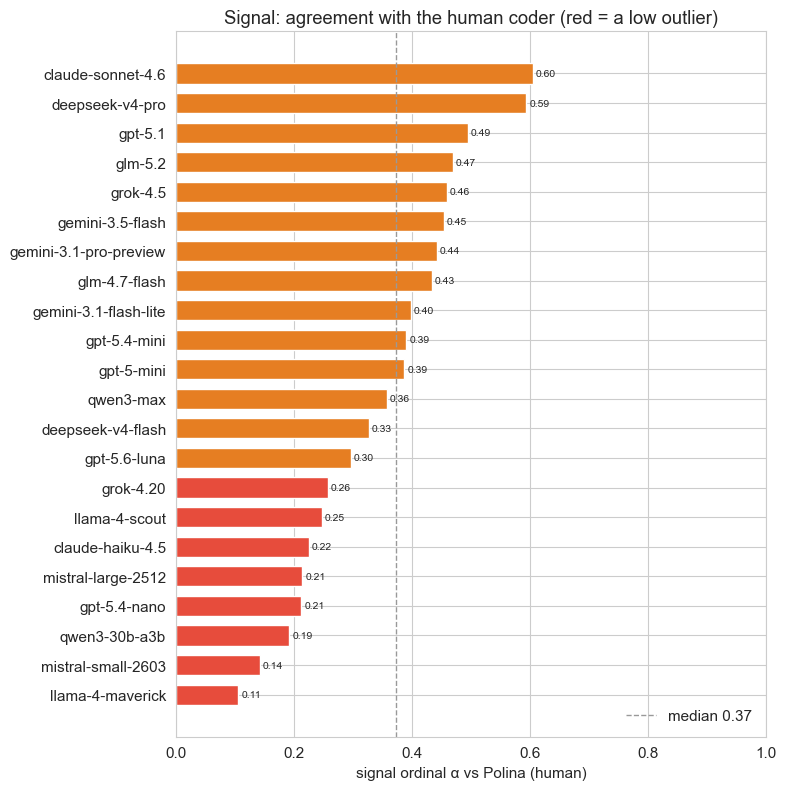

**What this shows:** vs-Polina signal α clusters low around **0.37** — even the human is only loosely tracked, best **claude-sonnet-4.6** (0.60). Consistent with §3: strength is the call humans and models alike find hardest to pin down, so vs-Polina here mostly confirms the task is fuzzy, not that any model is right.

In [5]:

vp = pd.DataFrame({"mshort": MODELS, "a": [VSP.get(m) for m in MODELS]}).dropna().sort_values("a")
fig, ax = plt.subplots(figsize=(8, 0.32*len(vp)+1))
colors = ["#e74c3c" if v < vp.a.median()-0.1 else "#e67e22" for v in vp.a]
ax.barh(vp.mshort, vp.a, color=colors, height=0.68)
for y,(_,r) in enumerate(vp.iterrows()): ax.text(r.a + 0.005, y, f"{r.a:.2f}", va="center", fontsize=7.5)
ax.axvline(vp.a.median(), ls="--", color="#999", lw=1, label=f"median {vp.a.median():.2f}")
ax.set_xlim(min(0, vp.a.min()-0.1), 1.0); ax.set_xlabel("signal ordinal α vs Polina (human)")
ax.set_title("Signal: agreement with the human coder (red = a low outlier)")
ax.legend(frameon=False, loc="lower right"); fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** vs-Polina signal α clusters low around **{vp.a.median():.2f}** — even the human is only "
  f"loosely tracked, best **{vp.iloc[-1].mshort}** ({vp.iloc[-1].a:.2f}). Consistent with §3: strength is the "
  f"call humans and models alike find hardest to pin down, so vs-Polina here mostly confirms the task is fuzzy, "
  f"not that any model is right."))


## 5. What low signal-agreement means for the pipeline

Signal strength feeds any downstream weighting that treats a 'strong' report as worth more than a 'weak' one. With cross-model (and human) agreement this low, that weighting rests on a judgement no two raters reliably reproduce. The honest implication: **treat signal as a coarse, low-confidence axis** — collapse it (e.g. strong-vs-not) rather than using three graded levels, or down-weight its role in clustering — until a better-specified rubric raises the ceiling. This is a task-property finding, not a model-selection one: no model rescues an underdetermined call.

## 6. Conclusion & scorecard

The consistency scorecard for signal — within-model, vs-Polina, divergence. No accuracy column, by design.

In [6]:

order = MODELS
rows = []
for m in order:
    div = 1 - np.nanmean([PAIR.loc[m,o] for o in order if o != m])
    rows.append(dict(model=m, within=WITHIN.get(m), vs_polina=VSP.get(m), divergence=div,
                     price=PRICES.get(next(c for c in CAND if c.split('/')[-1]==m), np.nan)))
SC = pd.DataFrame(rows).sort_values("vs_polina", ascending=False)
show = SC.copy()
for c in ["within","vs_polina","divergence"]: show[c] = show[c].round(2)
show["price"] = show["price"].map(lambda v: f"${v:g}" if pd.notna(v) else "?")
show.columns = ["model","within-model α","vs Polina α","divergence","$/1M in"]
display(HTML("<b>⑧ signal — consistency scorecard</b>" + show.to_html(index=False)))
lines = [
  f"- **Within-model is stable at temp 0** (median α {pd.Series(WITHIN).median():.2f}).",
  f"- **Cross-model agreement is the pipeline's lowest** (panel ordinal α {PANEL:.2f}) — models disagree on "
  f"strength far more than on direction.",
  f"- **vs-Polina is low and a screen** (median {SC.vs_polina.median():.2f}) — even humans are hard to track here.",
  f"- **Signal is an underdetermined axis.** No model fixes that; the actionable move is to coarsen or "
  f"down-weight signal downstream rather than trust three graded levels.",
]
display(Markdown("### Verdict\n\n" + "\n".join(lines)))


model,within-model α,vs Polina α,divergence,$/1M in
claude-sonnet-4.6,0.96,0.60,0.43,$3
deepseek-v4-pro,0.76,0.59,0.45,$0.435
gpt-5.1,0.93,0.49,0.46,$1.25
glm-5.2,0.83,0.47,0.39,$0.419
grok-4.5,0.90,0.46,0.46,$2
gemini-3.5-flash,0.90,0.45,0.46,$1.5
gemini-3.1-pro-preview,0.99,0.44,0.41,$2
glm-4.7-flash,0.75,0.43,0.42,$0.061
gemini-3.1-flash-lite,0.97,0.40,0.45,$0.25
gpt-5.4-mini,0.82,0.39,0.41,$0.75


### Verdict

- **Within-model is stable at temp 0** (median α 0.90).
- **Cross-model agreement is the pipeline's lowest** (panel ordinal α 0.59) — models disagree on strength far more than on direction.
- **vs-Polina is low and a screen** (median 0.37) — even humans are hard to track here.
- **Signal is an underdetermined axis.** No model fixes that; the actionable move is to coarsen or down-weight signal downstream rather than trust three graded levels.

## 7. Research limitations

- **Agreement ≠ validity** — a subjective ordinal call can be measured for consistency but not correctness.
- **Signal is intrinsically underdetermined** from 100–800-char posts, which caps ⑧'s ceiling regardless of
  model; low agreement here is largely a task property, not a model defect.
- **Polina is one contaminated-codebook coder** (signal set only on personal-use=yes items), so vs-Polina is a
  screen, not a ceiling.
- **Ordinal α depends on the level ordering** (weak < moderate < strong); the mapping of the models' and
  Polina's typo'd labels ("week", "medium") is normalized in compute_alphas.
- **K=3 repeats** — enough to show within-model stability at temp 0, not to estimate it tightly.
- Measures consistency of a measurement step, not any treatment effect.

In [7]:

import hashlib as _h
try: _sha = _h.sha256(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db","rb").read()).hexdigest()[:16]
except Exception: _sha = "n/a"
prov = pd.DataFrame({
  "item": ["run generated (UTC)","judgement","candidate models","reference","pairs / k","temperature","alpha impl","skill version"],
  "value": [MAN["generated_utc"], "8_signal_strength", len(CAND), MAN["reference"], f'{MAN["n_pairs"]} / {MAN["k"]}',
            MAN["temperature"], "compute_alphas.py (ordinal)", "research-assistant v2"],
})
display(HTML("<b>Provenance</b>" + prov.to_html(index=False)))
display(HTML('<div style="font-size:1.2em;font-weight:bold;font-style:italic;margin-top:1em">'
             'These findings reflect the consistency of a measurement pipeline, not population-level treatment '
             'effects. This is not medical advice.</div>'))


item,value
run generated (UTC),2026-07-18T02:08:00.613127+00:00
judgement,8_signal_strength
candidate models,22
reference,human_coder_a (Polina)
pairs / k,116 / 3
temperature,0.0
alpha impl,compute_alphas.py (ordinal)
skill version,research-assistant v2
